# Linear vs Exponential Decay — All Warehouses & WorkCodes

Compares linear and exponential time-decay incremental learning across every warehouse/workcode combination,
sweeping multiple hyperparameter values to find the best setting for each.

**Split:** 60% initial train | 25% update batches | 15% fixed test  
**N_BATCHES:** auto-scaled by data size, capped at 10  
**Metric:** chunk-level MAE/task on the fixed test set

**Decay parameters swept:**
- Linear: `MAX_DECAY_DAYS` ∈ {30, 60, 90, 120, 180}
- Exp: `lambda` ∈ {0.005, 0.01, 0.02, 0.05, 0.1}

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

import importlib
import feature_engineer
importlib.reload(feature_engineer)
from feature_engineer import get_engineered_df

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

PATH         = Path('../data/processed')
WAREHOUSES   = ['OE', 'OF', 'RT']
MAX_TIME     = 300
BLOCK_SIZE   = 50
RANDOM_STATE = 2026
UPDATE_TREES = 100

# Per-warehouse MAX_TIME overrides
# RT operations may take longer — update once you've inspected RT's time distribution
WAREHOUSE_MAX_TIME = {
    'OE': 300,
    'OF': 300,
    'RT': 300,
}

NOT_AVAILABLE = [
    'Travel_Distance',
    'same_aisle', 'same_lockey', 'same_location', 'same_level', 'diff_level',
    'time_of_day', 'day_of_week', 'hour',
]

XGB_PARAMS = dict(
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective='reg:tweedie',
    tweedie_variance_power=1.3,
    tree_method='hist',
    seed=RANDOM_STATE,
)

# --- Hyperparameter grids ---
LINEAR_GRIDS = [30, 60, 90, 120, 180]   # MAX_DECAY_DAYS values to try
EXP_GRIDS    = [0.005, 0.01, 0.02, 0.05, 0.1]  # lambda values to try

print('Setup complete.')
print(f'Linear grid (MAX_DECAY_DAYS): {LINEAR_GRIDS}')
print(f'Exp grid (lambda):            {EXP_GRIDS}')

Setup complete.
Linear grid (MAX_DECAY_DAYS): [30, 60, 90, 120, 180]
Exp grid (lambda):            [0.005, 0.01, 0.02, 0.05, 0.1]


In [9]:
# ── Helper functions ──────────────────────────────────────────────────────────

def resolve_data_path(warehouse):
    return PATH / f'{warehouse.lower()}_detailed.parquet'


def discover_workcodes(warehouse):
    df_raw = pd.read_parquet(resolve_data_path(warehouse))
    wc = df_raw['WorkCode'].astype(str).apply(
        lambda x: x.split('.')[0] if isinstance(x, str) else x
    )
    wc = wc.dropna()
    wc = wc[wc.str.lower() != 'nan']
    return sorted(wc.unique().tolist())


def load_engineered_data(warehouse, workcode, max_time=MAX_TIME):
    d, features_all, cat_cols_all = get_engineered_df(
        file_path=resolve_data_path(warehouse),
        warehouse=warehouse,
        max_time=max_time,
        work_code=workcode,
    )
    d = d.copy()
    d['Timestamp'] = pd.to_datetime(d['Timestamp'], errors='coerce')
    d = d.dropna(subset=['Timestamp']).copy()
    d['date']     = d['Timestamp'].dt.date
    d['WorkCode'] = d['WorkCode'].astype(str).str.replace('.0', '', regex=False)
    features = [f for f in features_all if f not in NOT_AVAILABLE]
    cat_cols = [c for c in cat_cols_all if c not in NOT_AVAILABLE]
    return d, features, cat_cols


def make_X_single(df, features, cat_cols, train_columns=None):
    X = pd.get_dummies(df[features], columns=cat_cols, drop_first=True)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    if train_columns is not None:
        X = X.reindex(columns=train_columns, fill_value=0)
    return X


def make_test_blocks(test_df):
    d = test_df.sort_values(['UserID', 'Timestamp']).copy()
    blocks, block_rows = [], []
    for (uid, day), g in d.groupby(['UserID', 'date'], sort=False):
        g = g.sort_values('Timestamp').reset_index().rename(columns={'index': 'orig_index'}).copy()
        for start in range(0, len(g), BLOCK_SIZE):
            chunk = g.iloc[start:start + BLOCK_SIZE].copy()
            if len(chunk) < BLOCK_SIZE: continue
            if chunk['WorkCode'].nunique() != 1: continue
            if (chunk['Time_Delta_sec'] > MAX_TIME).any(): continue
            block_id = f'{uid}_{day}_{start // BLOCK_SIZE}'
            chunk['BlockID'] = block_id
            block_rows.append(chunk)
            blocks.append({
                'BlockID':     block_id,
                'UserID':      uid,
                'date':        day,
                'WorkCode':    chunk['WorkCode'].iloc[0],
                'actual_time': chunk['Time_Delta_sec'].sum(),
            })
    block_df      = pd.DataFrame(blocks)
    block_rows_df = pd.concat(block_rows, ignore_index=True) if block_rows else pd.DataFrame()
    return block_df, block_rows_df


def eval_blocks(test_df, preds_array, train_columns):
    test_df = test_df.copy().reset_index(drop=True)
    block_df, block_rows_df = make_test_blocks(test_df)
    if block_df.empty:
        return np.nan, np.nan, 0
    temp = test_df.copy().reset_index().rename(columns={'index': 'orig_index'})
    temp['pred'] = preds_array
    block_rows_df = block_rows_df.merge(temp[['orig_index', 'pred']], on='orig_index', how='left')
    block_pred = (
        block_rows_df.groupby('BlockID')
        .agg(actual_time=('Time_Delta_sec', 'sum'), pred=('pred', 'sum'))
        .reset_index()
    )
    mae = mean_absolute_error(block_pred['actual_time'], block_pred['pred'])
    r2  = r2_score(block_pred['actual_time'], block_pred['pred'])
    return mae / BLOCK_SIZE, r2, len(block_pred)


def make_split(df, features, cat_cols, n_batches):
    df = df.sort_values(['date', 'Timestamp']).reset_index(drop=True)
    n_rows   = len(df)
    n_train  = int(n_rows * 0.60)
    n_test   = int(n_rows * 0.15)
    n_update = n_rows - n_train - n_test
    n_batch  = max(1, n_update // n_batches)

    train_df  = df.iloc[:n_train].copy().reset_index(drop=True)
    test_df   = df.iloc[n_train + n_update:].copy().reset_index(drop=True)
    batch_dfs = [
        df.iloc[n_train + i*n_batch : n_train + (i+1)*n_batch].copy().reset_index(drop=True)
        for i in range(n_batches)
    ]
    batch_dfs = [b for b in batch_dfs if len(b) > 0]

    X_train_init  = make_X_single(train_df, features, cat_cols)
    train_columns = X_train_init.columns.tolist()
    X_test        = make_X_single(test_df, features, cat_cols, train_columns=train_columns)
    y_test        = test_df['Time_Delta_sec'].astype(float)

    return train_df, batch_dfs, test_df, X_train_init, X_test, y_test, train_columns


def linear_weights(df, reference_date, max_days):
    days_old = (pd.Timestamp(reference_date) - pd.to_datetime(df['date'])).dt.days.clip(lower=0)
    return np.clip(1 - days_old / max_days, 0, 1).values


def exponential_weights(df, reference_date, lam):
    days_old = (pd.Timestamp(reference_date) - pd.to_datetime(df['date'])).dt.days.clip(lower=0)
    return np.exp(-lam * days_old).values


def run_decay_strategy(decay_fn, train_df, batch_dfs, test_df, features, cat_cols,
                       train_columns, dtrain, dtest, param):
    """
    Run one decay strategy (linear or exp) with a given hyperparameter.
    Returns list of MAE/task values: [initial, after_B1, after_B2, ...].
    decay_fn: callable(df, reference_date, param) -> weight array
    param: MAX_DECAY_DAYS (linear) or lambda (exp)
    """
    model = xgb.train(XGB_PARAMS, dtrain, num_boost_round=1200, verbose_eval=False)
    maes  = []
    mae, _, _ = eval_blocks(test_df, model.predict(dtest), train_columns)
    maes.append(mae)

    seen_df = train_df.copy()
    for batch_df in batch_dfs:
        seen_df = pd.concat([seen_df, batch_df], ignore_index=True)
        ref     = seen_df['date'].max()
        X_s     = make_X_single(seen_df, features, cat_cols, train_columns=train_columns)
        y_s     = seen_df['Time_Delta_sec'].astype(float)
        w_s     = decay_fn(seen_df, ref, param)
        model   = xgb.train(
            XGB_PARAMS,
            xgb.DMatrix(X_s, label=y_s, weight=w_s),
            num_boost_round=UPDATE_TREES,
            xgb_model=model,
            verbose_eval=False,
        )
        mae, _, _ = eval_blocks(test_df, model.predict(dtest), train_columns)
        maes.append(mae)

    return maes


print('Helpers defined.')

Helpers defined.


In [10]:
# ── Main sweep ────────────────────────────────────────────────────────────────
#
# all_results[warehouse][workcode] = {
#   'baseline':        float,
#   'linear_{days}':   [mae_initial, mae_b1, ...],
#   'exp_{lam}':       [mae_initial, mae_b1, ...],
# }

all_results = {}

for warehouse in WAREHOUSES:
    all_results[warehouse] = {}
    wh_max_time = WAREHOUSE_MAX_TIME.get(warehouse, MAX_TIME)

    try:
        workcodes = discover_workcodes(warehouse)
    except FileNotFoundError:
        print(f'\n{warehouse}: parquet file not found — skipping')
        continue

    print(f'\n{"="*65}')
    print(f'WAREHOUSE: {warehouse} | WorkCodes: {workcodes} | MAX_TIME: {wh_max_time}s')
    print(f'{"="*65}')

    for wc in workcodes:
        print(f'\n  ── WorkCode {wc} ──')

        try:
            df, features, cat_cols = load_engineered_data(warehouse, wc, max_time=wh_max_time)
        except Exception as e:
            print(f'  Could not load: {e} — skipping')
            continue

        if len(df) < 500:
            # Diagnostic: show time distribution so you can adjust WAREHOUSE_MAX_TIME
            try:
                df_raw = pd.read_parquet(resolve_data_path(warehouse))
                df_raw['WorkCode'] = df_raw['WorkCode'].astype(str).apply(
                    lambda x: x.split('.')[0] if isinstance(x, str) else x
                )
                wc_rows = df_raw[df_raw['WorkCode'] == wc]
                if len(wc_rows) > 0 and 'Time_Delta_sec' in df_raw.columns:
                    td = pd.to_numeric(wc_rows['Time_Delta_sec'], errors='coerce').dropna()
                    print(f'  {len(wc_rows):,} raw rows | Time_Delta_sec p50={td.quantile(.5):.0f}s '
                          f'p90={td.quantile(.9):.0f}s p99={td.quantile(.99):.0f}s '
                          f'→ {(td < wh_max_time).sum():,} pass filter — skipping (<500)')
                else:
                    print(f'  Too few rows ({len(df)}) — skipping')
            except Exception:
                print(f'  Too few rows ({len(df)}) — skipping')
            continue

        n_batches = max(3, min(10, int(len(df) * 0.25 / 1000)))
        print(f'  Rows: {len(df):,} | N_BATCHES: {n_batches}')

        train_df, batch_dfs, test_df, X_train_init, X_test, y_test, train_columns = make_split(
            df, features, cat_cols, n_batches
        )
        dtrain = xgb.DMatrix(X_train_init, label=train_df['Time_Delta_sec'].astype(float))
        dtest  = xgb.DMatrix(X_test)

        wc_results = {}

        # Baseline (no updates)
        model_base = xgb.train(XGB_PARAMS, dtrain, num_boost_round=1200, verbose_eval=False)
        mae_base, _, _ = eval_blocks(test_df, model_base.predict(dtest), train_columns)
        wc_results['baseline'] = mae_base

        # Linear decay sweep
        print(f'  Linear decay sweep...')
        for max_days in LINEAR_GRIDS:
            key = f'linear_{max_days}d'
            maes = run_decay_strategy(
                linear_weights, train_df, batch_dfs, test_df,
                features, cat_cols, train_columns, dtrain, dtest,
                param=max_days,
            )
            wc_results[key] = maes
            print(f'    linear_{max_days:3d}d: {maes[0]:.3f}s → {maes[-1]:.3f}s  '
                  f'({maes[-1]-mae_base:+.3f}s vs baseline)')

        # Exponential decay sweep
        print(f'  Exp decay sweep...')
        for lam in EXP_GRIDS:
            key = f'exp_{lam}'
            maes = run_decay_strategy(
                exponential_weights, train_df, batch_dfs, test_df,
                features, cat_cols, train_columns, dtrain, dtest,
                param=lam,
            )
            wc_results[key] = maes
            half_life = round(0.693 / lam, 1)
            print(f'    exp_lam={lam} (half-life={half_life}d): {maes[0]:.3f}s → {maes[-1]:.3f}s  '
                  f'({maes[-1]-mae_base:+.3f}s vs baseline)')

        all_results[warehouse][wc] = wc_results

        # Quick best summary
        best_key = min(
            (k for k in wc_results if k != 'baseline'),
            key=lambda k: wc_results[k][-1]
        )
        print(f'  → Best: {best_key} ({wc_results[best_key][-1]:.3f}s)  '
              f'Baseline: {mae_base:.3f}s')

print('\n\nAll done.')


WAREHOUSE: OE | WorkCodes: ['10', '20', '30'] | MAX_TIME: 300s

  ── WorkCode 10 ──
  Rows: 4,079 | N_BATCHES: 3
  Linear decay sweep...
    linear_ 30d: 24.775s → 23.633s  (-1.142s vs baseline)
    linear_ 60d: 24.775s → 23.751s  (-1.024s vs baseline)
    linear_ 90d: 24.775s → 23.753s  (-1.022s vs baseline)
    linear_120d: 24.775s → 23.644s  (-1.131s vs baseline)
    linear_180d: 24.775s → 24.061s  (-0.714s vs baseline)
  Exp decay sweep...
    exp_lam=0.005 (half-life=138.6d): 24.775s → 23.811s  (-0.964s vs baseline)
    exp_lam=0.01 (half-life=69.3d): 24.775s → 24.070s  (-0.705s vs baseline)
    exp_lam=0.02 (half-life=34.6d): 24.775s → 23.881s  (-0.893s vs baseline)
    exp_lam=0.05 (half-life=13.9d): 24.775s → 23.684s  (-1.090s vs baseline)
    exp_lam=0.1 (half-life=6.9d): 24.775s → 23.560s  (-1.215s vs baseline)
  → Best: exp_0.1 (23.560s)  Baseline: 24.775s

  ── WorkCode 20 ──
  Rows: 21,266 | N_BATCHES: 5
  Linear decay sweep...
    linear_ 30d: 8.687s → 7.086s  (-1.601s v

In [11]:
# ── Summary table: best config per combo ─────────────────────────────────────

rows = []
for wh, wc_dict in all_results.items():
    for wc, res in wc_dict.items():
        baseline = res['baseline']
        strategies = {k: v for k, v in res.items() if k != 'baseline'}
        if not strategies:
            continue

        # Best linear
        lin_keys  = [k for k in strategies if k.startswith('linear_')]
        best_lin  = min(lin_keys, key=lambda k: strategies[k][-1])
        best_lin_mae = strategies[best_lin][-1]

        # Best exp
        exp_keys  = [k for k in strategies if k.startswith('exp_')]
        best_exp  = min(exp_keys, key=lambda k: strategies[k][-1])
        best_exp_mae = strategies[best_exp][-1]

        overall_winner = 'Linear' if best_lin_mae <= best_exp_mae else 'Exp'

        rows.append({
            'Warehouse':        wh,
            'WorkCode':         wc,
            'Baseline MAE':     round(baseline, 3),
            'Best Linear':      best_lin,
            'Linear MAE':       round(best_lin_mae, 3),
            'Linear vs BL':     round(best_lin_mae - baseline, 3),
            'Best Exp':         best_exp,
            'Exp MAE':          round(best_exp_mae, 3),
            'Exp vs BL':        round(best_exp_mae - baseline, 3),
            'Winner':           overall_winner,
        })

summary_df = pd.DataFrame(rows)
print('Best configuration per warehouse/workcode:')
print()
display(summary_df.to_string(index=False))

Best configuration per warehouse/workcode:



'Warehouse WorkCode  Baseline MAE Best Linear  Linear MAE  Linear vs BL Best Exp  Exp MAE  Exp vs BL Winner\n       OE       10        24.775  linear_30d      23.633        -1.142  exp_0.1   23.560     -1.215    Exp\n       OE       20         8.687  linear_30d       7.086        -1.601  exp_0.1    7.142     -1.545 Linear\n       OE       30         7.288  linear_90d       6.631        -0.657 exp_0.05    6.595     -0.693    Exp'

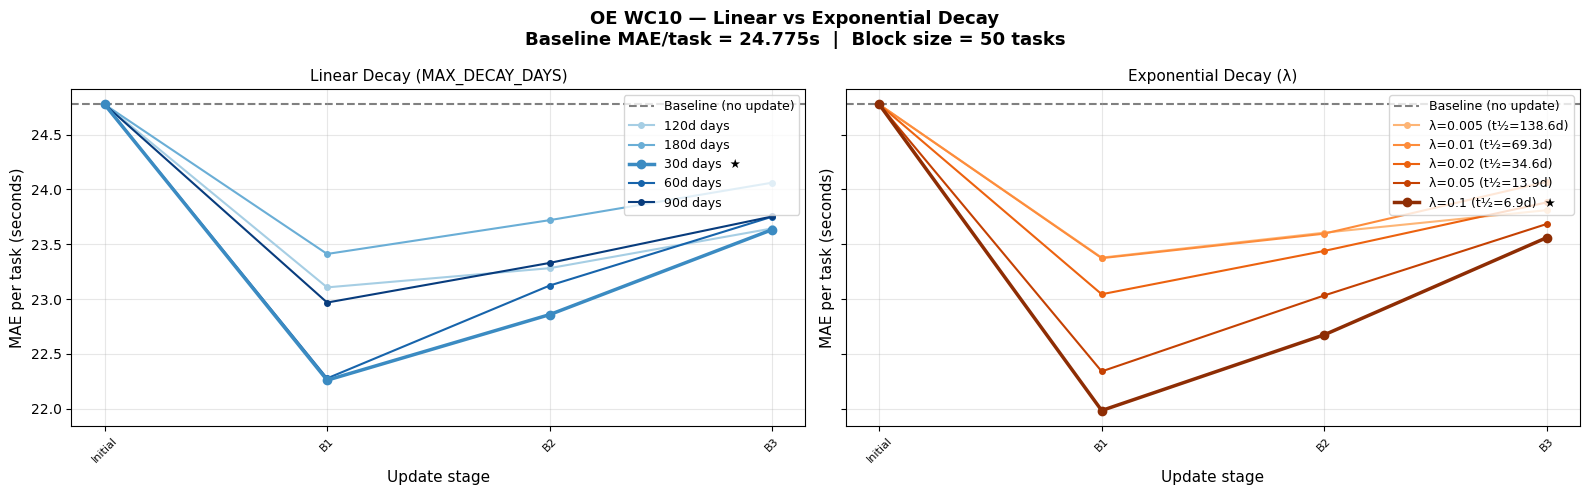


OE WC10  |  Baseline: 24.775s
Config                   Initial     Final  vs Baseline
-------------------------------------------------------
exp_0.1                   24.775    23.560       -1.215  ← best
linear_30d                24.775    23.633       -1.142
linear_120d               24.775    23.644       -1.131
exp_0.05                  24.775    23.684       -1.090
linear_60d                24.775    23.751       -1.024
linear_90d                24.775    23.753       -1.022
exp_0.005                 24.775    23.811       -0.964
exp_0.02                  24.775    23.881       -0.893
linear_180d               24.775    24.061       -0.714
exp_0.01                  24.775    24.070       -0.705



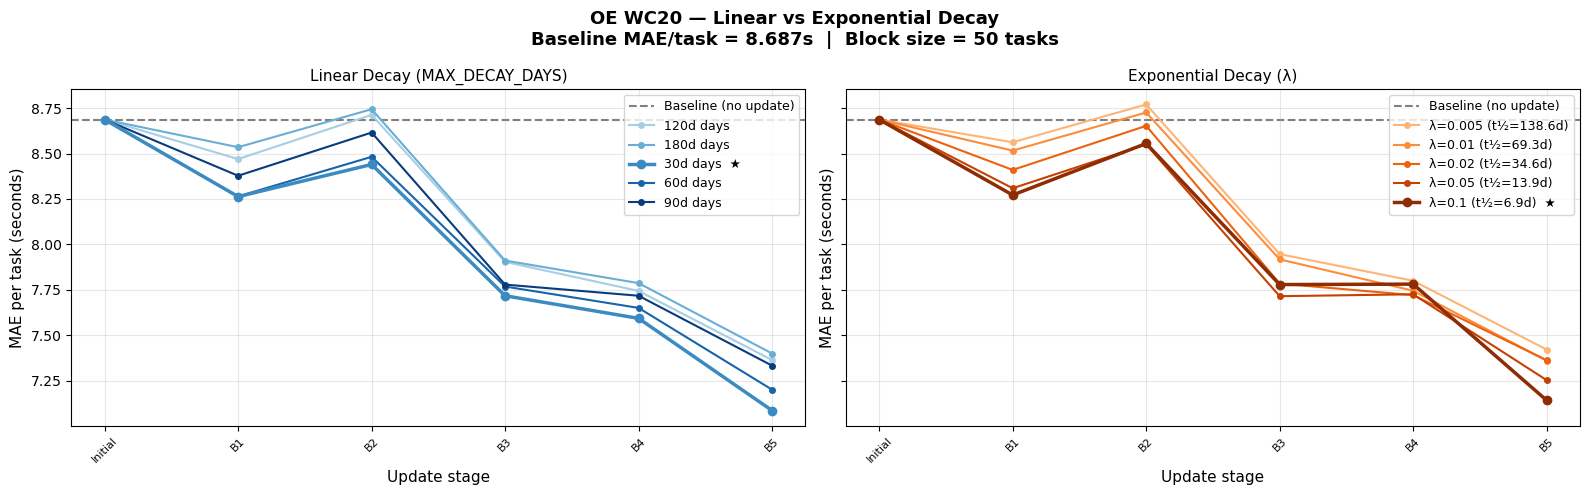


OE WC20  |  Baseline: 8.687s
Config                   Initial     Final  vs Baseline
-------------------------------------------------------
linear_30d                 8.687     7.086       -1.601  ← best
exp_0.1                    8.687     7.142       -1.545
linear_60d                 8.687     7.200       -1.486
exp_0.05                   8.687     7.253       -1.434
linear_90d                 8.687     7.333       -1.354
exp_0.01                   8.687     7.360       -1.327
exp_0.02                   8.687     7.363       -1.324
linear_120d                8.687     7.363       -1.323
linear_180d                8.687     7.399       -1.287
exp_0.005                  8.687     7.421       -1.266



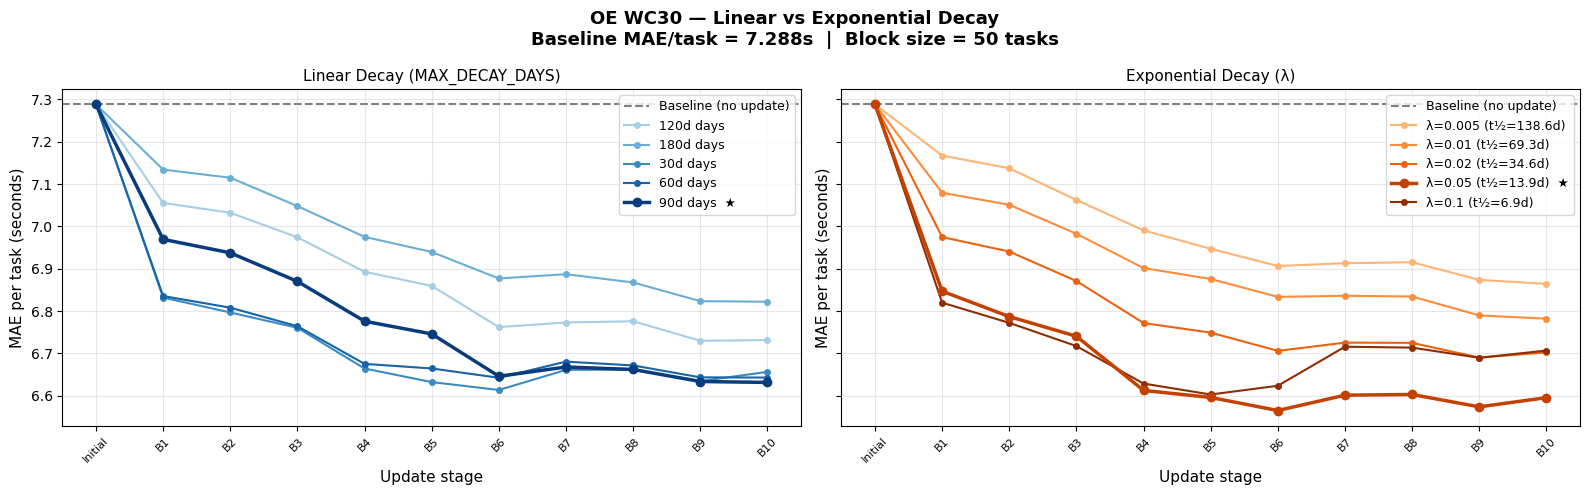


OE WC30  |  Baseline: 7.288s
Config                   Initial     Final  vs Baseline
-------------------------------------------------------
exp_0.05                   7.288     6.595       -0.693  ← best
linear_90d                 7.288     6.631       -0.657
linear_60d                 7.288     6.643       -0.645
linear_30d                 7.288     6.656       -0.632
exp_0.02                   7.288     6.702       -0.586
exp_0.1                    7.288     6.707       -0.581
linear_120d                7.288     6.731       -0.557
exp_0.01                   7.288     6.782       -0.506
linear_180d                7.288     6.822       -0.466
exp_0.005                  7.288     6.864       -0.424



In [12]:
# ── Per-combo plot: all linear configs vs all exp configs over batches ────────

LIN_COLORS = plt.cm.Blues(np.linspace(0.35, 0.95, len(LINEAR_GRIDS)))
EXP_COLORS = plt.cm.Oranges(np.linspace(0.35, 0.95, len(EXP_GRIDS)))

for wh, wc_dict in all_results.items():
    for wc, res in wc_dict.items():
        baseline  = res['baseline']
        lin_keys  = sorted([k for k in res if k.startswith('linear_')])
        exp_keys  = sorted([k for k in res if k.startswith('exp_')])

        n_points = max(len(res[k]) for k in lin_keys + exp_keys)
        labels   = ['Initial'] + [f'B{i+1}' for i in range(n_points - 1)]

        fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
        fig.suptitle(
            f'{wh} WC{wc} — Linear vs Exponential Decay\n'
            f'Baseline MAE/task = {baseline:.3f}s  |  Block size = {BLOCK_SIZE} tasks',
            fontsize=13, fontweight='bold'
        )

        for ax, keys, colors, family_label in [
            (axes[0], lin_keys, LIN_COLORS, 'Linear Decay (MAX_DECAY_DAYS)'),
            (axes[1], exp_keys, EXP_COLORS, 'Exponential Decay (λ)'),
        ]:
            # Baseline reference
            ax.axhline(baseline, color='gray', linestyle='--', linewidth=1.5,
                       label='Baseline (no update)', zorder=1)

            for key, color in zip(keys, colors):
                maes  = res[key]
                # Parse label
                if key.startswith('linear_'):
                    days  = key.split('_')[1]
                    label = f'{days} days'
                else:
                    lam   = float(key.split('_')[1])
                    hl    = round(0.693 / lam, 1)
                    label = f'λ={lam} (t½={hl}d)'

                is_best = (maes[-1] == min(res[k][-1] for k in keys))
                lw  = 2.5 if is_best else 1.5
                ms  = 6   if is_best else 4
                zo  = 3   if is_best else 2
                lbl = label + '  ★' if is_best else label

                ax.plot(range(len(maes)), maes,
                        marker='o', linewidth=lw, markersize=ms,
                        color=color, label=lbl, zorder=zo)

            ax.set_xticks(range(n_points))
            ax.set_xticklabels(labels, rotation=45, fontsize=8)
            ax.set_xlabel('Update stage', fontsize=11)
            ax.set_ylabel('MAE per task (seconds)', fontsize=11)
            ax.set_title(family_label, fontsize=11)
            ax.legend(fontsize=9, loc='upper right')
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Per-combo summary table
        print(f'\n{wh} WC{wc}  |  Baseline: {baseline:.3f}s')
        print(f'{"Config":<22} {"Initial":>9} {"Final":>9} {"vs Baseline":>12}')
        print('-' * 55)
        all_keys = lin_keys + exp_keys
        for key in sorted(all_keys, key=lambda k: res[k][-1]):
            maes = res[key]
            diff = maes[-1] - baseline
            flag = '  ← best' if key == min(all_keys, key=lambda k: res[k][-1]) else ''
            print(f'{key:<22} {maes[0]:>9.3f} {maes[-1]:>9.3f} {diff:>+12.3f}{flag}')
        print()

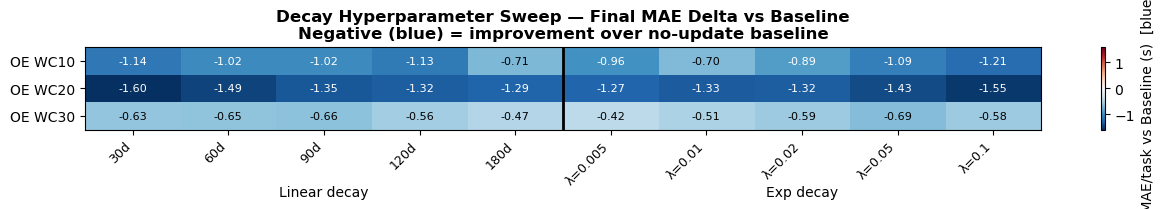

In [13]:
# ── Heatmap: final MAE improvement vs baseline for every config × combo ───────
# Rows = warehouse/workcode combos, Cols = hyperparameter configs
# Color = MAE delta vs baseline (blue = better, red = worse)

combos   = [(wh, wc) for wh in all_results for wc in all_results[wh]]
lin_cols = [f'linear_{d}d' for d in LINEAR_GRIDS]
exp_cols = [f'exp_{l}'     for l in EXP_GRIDS]
all_cols = lin_cols + exp_cols

col_labels = (
    [f'{d}d' for d in LINEAR_GRIDS] +
    [f'λ={l}' for l in EXP_GRIDS]
)
row_labels = [f'{wh} WC{wc}' for wh, wc in combos]

matrix = np.full((len(combos), len(all_cols)), np.nan)
for r, (wh, wc) in enumerate(combos):
    res      = all_results[wh][wc]
    baseline = res['baseline']
    for c, key in enumerate(all_cols):
        if key in res:
            matrix[r, c] = res[key][-1] - baseline

vmax = np.nanmax(np.abs(matrix))

fig, ax = plt.subplots(figsize=(13, max(4, len(combos) * 0.7)))
im = ax.imshow(matrix, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(len(all_cols)))
ax.set_xticklabels(col_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(combos)))
ax.set_yticklabels(row_labels, fontsize=10)

# Divider between linear and exp columns
ax.axvline(len(lin_cols) - 0.5, color='black', linewidth=2)
ax.text(len(lin_cols)/2 - 0.5, -0.8, 'Linear decay', ha='center', fontsize=10,
        transform=ax.get_xaxis_transform())
ax.text(len(lin_cols) + len(exp_cols)/2 - 0.5, -0.8, 'Exp decay', ha='center', fontsize=10,
        transform=ax.get_xaxis_transform())

# Annotate cells
for r in range(len(combos)):
    for c in range(len(all_cols)):
        val = matrix[r, c]
        if not np.isnan(val):
            txt = f'{val:+.2f}'
            color = 'white' if abs(val) > vmax * 0.55 else 'black'
            ax.text(c, r, txt, ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im, ax=ax, label='Final MAE/task vs Baseline (s)  [blue = better]')
ax.set_title('Decay Hyperparameter Sweep — Final MAE Delta vs Baseline\n'
             'Negative (blue) = improvement over no-update baseline',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# ── Global recommendation ─────────────────────────────────────────────────────

print('='*65)
print('GLOBAL RECOMMENDATION')
print('='*65)

# Count wins and average improvement per config across all combos
lin_cols = [f'linear_{d}d' for d in LINEAR_GRIDS]
exp_cols = [f'exp_{l}'     for l in EXP_GRIDS]

config_stats = {}
for key in lin_cols + exp_cols:
    improvements = []
    for wh in all_results:
        for wc in all_results[wh]:
            res = all_results[wh][wc]
            if key in res:
                improvements.append(res['baseline'] - res[key][-1])
    config_stats[key] = {
        'avg_improvement': np.mean(improvements) if improvements else np.nan,
        'n_positive':      sum(1 for x in improvements if x > 0),
        'n_combos':        len(improvements),
    }

# Best overall config
best_config = max(config_stats, key=lambda k: config_stats[k]['avg_improvement'])

print(f'\n{"Config":<22} {"Avg Improvement":>18} {"Beats Baseline":>16}')
print('-' * 60)
for key in sorted(config_stats, key=lambda k: -config_stats[k]['avg_improvement']):
    s   = config_stats[key]
    imp = s['avg_improvement']
    n   = s['n_combos']
    pos = s['n_positive']
    flag = '  ← best' if key == best_config else ''
    print(f'{key:<22} {imp:>+18.4f}s {pos:>7}/{n}{flag}')

print(f'\nRecommended config: {best_config}')
if best_config.startswith('linear_'):
    days = int(best_config.split('_')[1].replace('d',''))
    print(f'  → Use Linear Decay with MAX_DECAY_DAYS = {days}')
    print(f'  → Interpretation: picks older than {days} days receive zero weight')
else:
    lam = float(best_config.split('_')[1])
    hl  = round(0.693 / lam, 1)
    print(f'  → Use Exponential Decay with lambda = {lam}')
    print(f'  → Interpretation: pick weight halves every {hl} days')

GLOBAL RECOMMENDATION

Config                    Avg Improvement   Beats Baseline
------------------------------------------------------------
linear_30d                        +1.1250s       3/3  ← best
exp_0.1                           +1.1138s       3/3
exp_0.05                          +1.0723s       3/3
linear_60d                        +1.0518s       3/3
linear_90d                        +1.0109s       3/3
linear_120d                       +1.0036s       3/3
exp_0.02                          +0.9345s       3/3
exp_0.005                         +0.8846s       3/3
exp_0.01                          +0.8460s       3/3
linear_180d                       +0.8224s       3/3

Recommended config: linear_30d
  → Use Linear Decay with MAX_DECAY_DAYS = 30
  → Interpretation: picks older than 30 days receive zero weight
